In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

from xgboost import XGBClassifier

In [2]:
NHSTA_HEADERS = [
    "CMPLID", "ODINO", "MFR_NAME", "MAKETXT", "MODELTXT", "YEARTXT", "CRASH",
    "FAILDATE", "FIRE", "INJURED", "DEATHS", "COMPDESC", "CITY", "STATE",
    "VIN", "DATEA", "LDATE", "MILES", "OCCURENCES", "CDESCR", "CMPL_TYPE",
    "POLICE_RPT_YN", "PURCH_DT", "ORIG_OWNER_YN", "ANTI_BRAKES_YN",
    "CRUISE_CONT_YN", "NUM_CYLS", "DRIVE_TRAIN", "FUEL_SYS", "FUEL_TYPE",
    "TRANS_TYPE", "VEH_SPEED", "DOT", "TIRE_SIZE", "LOC_OF_TIRE",
    "TIRE_FAIL_TYPE", "ORIG_EQUIP_YN", "MANUF_DT", "SEAT_TYPE",
    "RESTRAINT_TYPE", "DEALER_NAME", "DEALER_TEL", "DEALER_CITY",
    "DEALER_STATE", "DEALER_ZIP", "PROD_TYPE", "REPAIRED_YN",
    "MEDICAL_ATTN", "VEHICLES_TOWED_YN", "STATE_OF_INCIDENT", "VEHICLE_OPERATOR"
]

PASSENGER_MAKES = {
    "ACURA", "AUDI", "BMW",
    "BUICK", "CADILLAC", "CHEVROLET", "CHRYSLER", "DODGE", 
    "FORD", "GMC", "HONDA", "HUMMER", "HYUNDAI",
    "INFINITI", "JAGUAR", "JEEP", "KIA", "LAND ROVER",
    "LEXUS", "LINCOLN", "MAZDA",
    "MERCEDES-BENZ", "MERCEDES", "MINI",
    "MITSUBISHI", "NISSAN",
    "PORSCHE", "RAM",
    "SUBARU", "TESLA", "TOYOTA", "VOLKSWAGEN", "VOLVO"
}

SAFETY_KEYPHRASES = [
    "air bags",
    "airbag",
    "airbags deployed",
    "auto seat belt",
    "auto stop",
    "auto stop start",
    "automatic emergency braking",
    "backup assist disengaged",
    "battery failing",
    "battery fails",
    "battery fails driving",
    "battery fire",
    "battery significant hazard",
    "bluetooth",
    "bluetooth safety hazard",
    "brake failure",
    "brake fluid",
    "braking failed",
    "braking failed respond",
    "braking forward collision",
    "burned driving trailer",
    "burning smell electrical",
    "camera",
    "camera temporarily unavailable",
    "charging failure",
    "check engine light",
    "collision jolt",
    "collision warning activates",
    "coolant leaked engine",
    "crack windshield",
    "cracked windshield",
    "dct shudders sluggish",
    "defect transmission",
    "delay transmission engaging",
    "drive train malfunction",
    "electrical fire",
    "electrical malfunction",
    "electrical malfunctions",
    "electrical short",
    "emergency brake",
    "emergency brake engaged",
    "emergency braking",
    "emergency braking activated",
    "emergency braking aeb",
    "emergency braking slammed",
    "engine cuts out",
    "engine misfiring",
    "engine overheating",
    "engine seized",
    "engine shuts off",
    "engine stalls",
    "ev unable restart",
    "examined overheating electrical",
    "failing battery thermostat",
    "failing fuel engine",
    "false alarms powertrain",
    "false crash",
    "false crash event",
    "falsely triggered crash",
    "feel transmission dropping",
    "fuel leaking",
    "fuel pump failed",
    "fully charged danger",
    "hard brake",
    "highway tire separated",
    "ignition coil failed",
    "issue adaptive cruise",
    "lane assist active",
    "lane departure steering",
    "leak transfer case",
    "lost power steering",
    "low oil warning",
    "oil consumption issue",
    "oil leak",
    "overheating electrical failures",
    "passenger airbag light",
    "phantom braking",
    "power loss driving",
    "power steering failed",
    "power steering malfunctioned",
    "pre sense braking",
    "rear camera",
    "rear window exploded",
    "rear windshield",
    "rearview camera",
    "reverse rearview camera",
    "roof shattered",
    "safety restraint warning",
    "seat belt",
    "seat belt warning",
    "seat belts",
    "seat belts fail",
    "seat belts lock",
    "seat belts malfunctioned",
    "steering failed",
    "steering issues",
    "steering stopped",
    "steering wheel locked",
    "steering wheel seized",
    "sudden loss drive",
    "sudden loss power",
    "sun roof shattered",
    "sunroof exploded",
    "sunroof exploded driving",
    "sunroof exploded randomly",
    "sunroof exploded shattered",
    "sunroof glass shattered",
    "sunroof popped shattered",
    "sunroof shattered",
    "sunroof spontaneously shattered",
    "thermal runaway",
    "timing chain snapped",
    "tire blew",
    "tire failure",
    "trailer plug melted",
    "transmission died",
    "transmission dying",
    "transmission engages delay",
    "transmission failed",
    "transmission issues",
    "transmission jerks decelerating",
    "transmission transfer case",
    "turbo fails",
    "turtle mode error",
    "unsafe brakes sudden",
    "warning braking engaged",
    "windshield crack",
    "windshield cracked",
    "wiring harness" 
]

In [3]:
complaint_data_10_14 = pd.read_csv('Complaint_2010_2014.csv', header = None, names = NHSTA_HEADERS)
complaint_data_15_19 = pd.read_csv('Complaint_2015_2019.csv', header = None, names = NHSTA_HEADERS)
complaint_data_20_24 = pd.read_csv('Complaint_2020_2024.csv', header = None, names = NHSTA_HEADERS)
complaint_data_25_26 = pd.read_csv('Complaint_2025_2026.csv', header = None, names = NHSTA_HEADERS)
complaint_data_combined = pd.concat([complaint_data_10_14, complaint_data_15_19, complaint_data_20_24, complaint_data_25_26])

C:\Users\Work\AppData\Local\Temp\ipykernel_20328\1991020276.py:1: DtypeWarning: Columns (41,44) have mixed types. Specify dtype option on import or set low_memory=False.
  complaint_data_10_14 = pd.read_csv('Complaint_2010_2014.csv', header = None, names = NHSTA_HEADERS)
C:\Users\Work\AppData\Local\Temp\ipykernel_20328\1991020276.py:2: DtypeWarning: Columns (28,41,44) have mixed types. Specify dtype option on import or set low_memory=False.
  complaint_data_15_19 = pd.read_csv('Complaint_2015_2019.csv', header = None, names = NHSTA_HEADERS)
C:\Users\Work\AppData\Local\Temp\ipykernel_20328\1991020276.py:3: DtypeWarning: Columns (27,28,29,30,33,38,41,44) have mixed types. Specify dtype option on import or set low_memory=False.
  complaint_data_20_24 = pd.read_csv('Complaint_2020_2024.csv', header = None, names = NHSTA_HEADERS)
C:\Users\Work\AppData\Local\Temp\ipykernel_20328\1991020276.py:4: DtypeWarning: Columns (29,41,44,49,50) have mixed types. Specify dtype option on import or set lo

In [4]:
complaint_data_combined["YEARTXT"] = pd.to_numeric(complaint_data_combined["YEARTXT"], errors="coerce")
complaint_data_combined = complaint_data_combined.dropna(subset=["YEARTXT"])
complaint_data_combined["YEARTXT"] = complaint_data_combined["YEARTXT"].astype(int)
complaint_data_combined = complaint_data_combined.loc[complaint_data_combined['YEARTXT'] != 9999]

complaint_data_combined = complaint_data_combined[complaint_data_combined["MAKETXT"].str.upper().isin(PASSENGER_MAKES)]
complaint_data_combined.loc[complaint_data_combined["MAKETXT"] == 'MERCEDES', "MAKETXT"] = "MERCEDES-BENZ"

complaint_data_combined["CRASH"] = complaint_data_combined["CRASH"].map({"Y": 1, "N": 0}).fillna(0).astype(int)

numeric_dates = pd.to_numeric(complaint_data_combined["LDATE"], errors="coerce")
complaint_data_combined["LDATE"] = numeric_dates.astype("Int64").astype(str)
complaint_data_combined['FAILDATE'] = pd.to_datetime(complaint_data_combined['FAILDATE'].astype(str), format='%Y%m%d', errors='coerce')
complaint_data_combined['LDATE'] = pd.to_datetime(complaint_data_combined['LDATE'].astype(str), format='%Y%m%d', errors='coerce')

complaint_data_combined = complaint_data_combined.rename(columns = {
    "MAKETXT": "MAKE",
    "MODELTXT": "MODEL",
    "YEARTXT": "YEAR"})

complaint_data_combined.drop_duplicates(subset = ["ODINO"])

complaint_data_combined['RELEASE_DATE'] = pd.to_datetime(
    complaint_data_combined['YEAR'].astype(str) + '-01-01'
)
complaint_data_combined['within_12_months'] = (
    (complaint_data_combined['LDATE'] - complaint_data_combined['RELEASE_DATE']).dt.days.between(0, 365)
)

complaint_data_combined['vehicle_age_at_complaint'] = complaint_data_combined['LDATE'].dt.year - complaint_data_combined['YEAR']

In [5]:
HIGH_RISK = ['air bag', 'electrical', 'power train']

risk_pattern = '|'.join(HIGH_RISK)

complaint_data_combined.loc[complaint_data_combined['COMPDESC'].str.contains(risk_pattern, case=False, na=False), 'high_risk'] = 1

NameError: name 'recall_data_combined' is not defined

In [8]:
recall_data_combined = pd.read_csv('recalled_2010_2020.csv')
recall_data_combined = recall_data_combined[recall_data_combined["MAKE"].str.upper().isin(PASSENGER_MAKES)]
recall_data_combined = recall_data_combined.drop_duplicates(subset = ["MAKE", "MODEL", "YEAR"], keep='last')
recall_data_combined = recall_data_combined.rename(columns = {"MODEL YEAR": "YEAR"})
recall_data_combined['Recall'] = 1

In [10]:
complaint_data_combined_year = complaint_data_combined[(complaint_data_combined["YEAR"] >= 2015) & (complaint_data_combined["YEAR"] <= 2020)]
complaint_recall = complaint_data_combined_year.merge(recall_data_combined[['MAKE', 'MODEL', 'YEAR', 'Recall']], on = ['MAKE', 'MODEL', 'YEAR'], how = 'left')
complaint_recall["Recall"] = pd.to_numeric(complaint_recall["Recall"], errors="coerce")
complaint_recall["Recall"] = complaint_recall["Recall"].fillna(0)
complaint_recall["Recall"] = complaint_recall["Recall"].astype(int)

In [14]:
component_recall = (
    complaint_recall.groupby('COMPDESC')['Recall']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'recall_rate', 'count': 'total'})
    .sort_values('recall_rate', ascending=False)
)

print(component_recall[component_recall['total'] > 1000])

                                                    recall_rate  total
COMPDESC                                                              
STRUCTURE                                              0.986993   1999
FUEL SYSTEM, GASOLINE                                  0.986800   2803
FORWARD COLLISION AVOIDANCE: ADAPTIVE CRUISE CO...     0.985927   2558
ENGINE AND ENGINE COOLING                              0.984474   5668
SERVICE BRAKES, HYDRAULIC                              0.983587   2498
BACK OVER PREVENTION                                   0.980535   1644
FORWARD COLLISION AVOIDANCE: AUTOMATIC EMERGENC...     0.978296   4884
SEATS                                                  0.972331   3325
STEERING                                               0.970336  21575
STRUCTURE:BODY                                         0.969564  10481
SERVICE BRAKES                                         0.968684  21395
POWER TRAIN                                            0.968400  41709
VEHICL

In [ ]:
raw_data = complaint_data_combined[(complaint_data_combined["YEAR"] >= 2022) & (complaint_data_combined["YEAR"] <= 2026)]

In [ ]:
complaint_data_combined = complaint_data_combined.groupby(["MAKE", "MODEL", "YEAR"]).agg(
    complaint_count = ("ODINO", "count"),
    crash_count = ("CRASH", "sum"),
    fire_count = ("FIRE", "sum"),  
    injured_count = ("INJURED", "sum"),
    death_count = ("DEATHS", "sum"),
    medical_count = ("MEDICAL_ATTN", "sum"),
    tow_count = ("VEHICLES_TOWED_YN", "sum"),
    police_count = ("POLICE_RPT_YN", "sum"),
    first_complaint_date = ("FAILDATE", "min"),
    last_complaint_date = ("FAILDATE", "max"),
    complaints_first_12m = ('within_12_months', 'sum'),
    median_mileage = ("MILES", "median"),
    median_age = ("vehicle_age_at_complaint", "median"),
    component = ("COMPDESC", lambda x: list(x.dropna())),
    description = ("CDESCR", lambda x: " ".join(x.dropna()))).reset_index()

complaint_data_combined['crash_ratio'] = complaint_data_combined['crash_count'] / complaint_data_combined['complaint_count']
complaint_data_combined['median_mileage'] = complaint_data_combined['median_mileage'].fillna(0)
complaint_data_combined = complaint_data_combined.loc[complaint_data_combined['complaint_count'] >= 10]

In [ ]:
recall_data_combined = pd.read_csv('recalled_2010_2020.csv')
recall_data_combined = recall_data_combined[recall_data_combined["MAKE"].str.upper().isin(PASSENGER_MAKES)]
recall_data_combined = recall_data_combined.drop_duplicates(subset = ["MAKE", "MODEL", "YEAR"], keep='last')
recall_data_combined = recall_data_combined.rename(columns = {"MODEL YEAR": "YEAR"})
recall_data_combined['Recall'] = 1

In [ ]:
complaint_data_combined_year = complaint_data_combined[(complaint_data_combined["YEAR"] >= 2015) & (complaint_data_combined["YEAR"] <= 2020)]
complaint_recall = complaint_data_combined_year.merge(recall_data_combined[['MAKE', 'MODEL', 'YEAR', 'Recall']], on = ['MAKE', 'MODEL', 'YEAR'], how = 'left')
complaint_recall["Recall"] = pd.to_numeric(complaint_recall["Recall"], errors="coerce")
complaint_recall["Recall"] = complaint_recall["Recall"].fillna(0)
complaint_recall["Recall"] = complaint_recall["Recall"].astype(int)

In [86]:
def keybert_safety_score(text):
    if not text:
        return 0
    text = str(text).lower()
    tokens = set(re.findall(r'\b\w+\b', text))
    
    score = 0
    for phrase in SAFETY_KEYPHRASES:
        phrase_tokens = set(phrase.lower().split())
        overlap = len(phrase_tokens & tokens) / len(phrase_tokens)
        if overlap >= 0.75:
            score += 1
    return score

In [87]:
complaint_recall["keybert_safety_score"] = complaint_recall["description"].apply(keybert_safety_score)
complaint_recall["keybert_per_complaint"] = complaint_recall["keybert_safety_score"] / complaint_recall["complaint_count"]
print(complaint_recall.groupby("Recall")[["keybert_safety_score"]].median())

        keybert_safety_score
Recall                      
0                       16.0
1                       43.5


In [88]:
features = [
    "crash_ratio",
    'keybert_safety_score',
    "median_mileage",
    "complaints_first_12m"
]

X = complaint_recall[features]
y = complaint_recall["Recall"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [89]:
complaint_recall['Recall'].value_counts()

Recall
1    1392
0     204
Name: count, dtype: int64

In [90]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
lr = LogisticRegressionCV(class_weight='balanced', cv=cv, random_state=42, max_iter = 400)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

In [62]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
t)

rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]


TypeError: RandomForestClassifier.__init__() got an unexpected keyword argument 'cv'

In [64]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

In [70]:
print(f"Logistic Regression AUC: {roc_auc_score(y_test, lr_proba):.3f}")
print(f"Random Forest AUC: {roc_auc_score(y_test, rf_proba):.3f}")
print(f"XGBoost AUC: {roc_auc_score(y_test, xgb_proba):.3f}")

Logistic Regression AUC: 0.749
Random Forest AUC: 0.665
XGBoost AUC: 0.663


In [68]:
scoring = {
    'roc_auc':   make_scorer(roc_auc_score)
}

for name, model in [("XGBoost", xgb), 
                     ("Logistic Regression", lr),
                     ("Random Forest", rf)]:
    
    results = cross_validate(model, X_train, y_train, 
                             cv = cv, scoring = scoring)
    
    print(f"\n{name} Cross Validation (5-fold):")
    print(f"  AUC:       {results['test_roc_auc'].mean():.3f}")


XGBoost Cross Validation (5-fold):
  AUC:       0.606

Logistic Regression Cross Validation (5-fold):
  AUC:       0.705

Random Forest Cross Validation (5-fold):
  AUC:       0.538


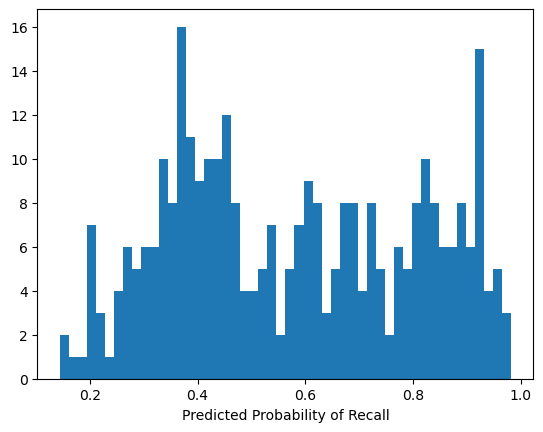

0.5801472641038481


In [15]:
plt.hist(lr_proba, bins=50)
plt.xlabel('Predicted Probability of Recall')
plt.show()

print(lr_proba.mean())  

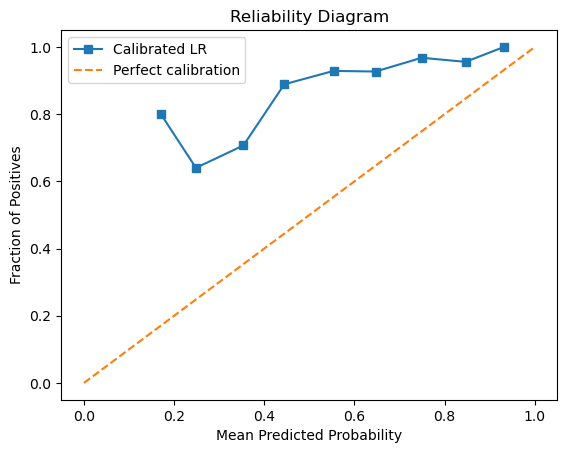

In [20]:
from sklearn.calibration import calibration_curve

fraction_of_positives, mean_predicted = calibration_curve(y_test, lr_proba, n_bins=10)

plt.plot(mean_predicted, fraction_of_positives, 's-', label='Calibrated LR')
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Reliability Diagram')
plt.show()


In [30]:
calibrated_lr = CalibratedClassifierCV(lr, method='sigmoid', cv=5)
calibrated_lr.fit(X_train_scaled, y_train)
prob_calibrated = calibrated_lr.predict_proba(X_test_scaled)[:, 1]

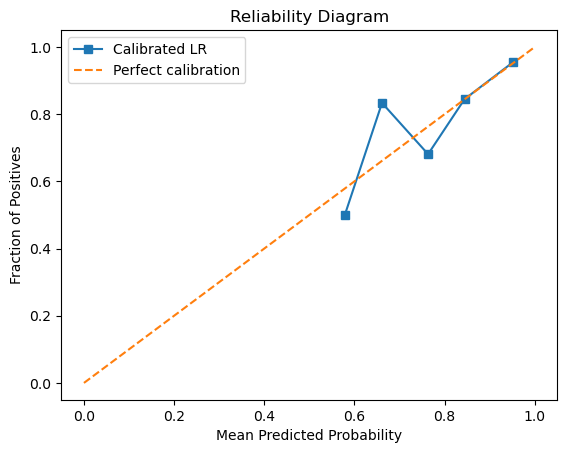

In [32]:
fraction_of_positives, mean_predicted = calibration_curve(y_test, prob_calibrated, n_bins=10)

plt.plot(mean_predicted, fraction_of_positives, 's-', label='Calibrated LR')
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Reliability Diagram')
plt.show()


In [34]:
print(prob_calibrated.min(), prob_calibrated.max())
print(pd.Series(prob_calibrated).describe())

# How many below threshold
print(f"Below 0.5: {(prob_calibrated < 0.5).sum()}")
print(f"Below 0.6: {(prob_calibrated < 0.6).sum()}")

0.5744072594284166 0.9940302040736118
count    320.000000
mean       0.876408
std        0.089869
min        0.574407
25%        0.813156
50%        0.897555
75%        0.956559
max        0.994030
dtype: float64
Below 0.5: 0
Below 0.6: 2


In [53]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [239]:
print(y.value_counts(normalize=True))
print("Class mapping:", model.classes_)

# Make sure class 1 = recalled
probs = model.predict_proba(X_test)[:, 1]
print("Mean predicted prob:", probs.mean())  

Recall
1    0.87218
0    0.12782
Name: proportion, dtype: float64


NameError: name 'model' is not defined

In [156]:
from sklearn.model_selection import train_test_split

# Split BEFORE anything
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2)

# Step 1: scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)      # ✅ transform only
X_test_scaled = scaler.transform(X_test)    # ✅ transform only

# Step 2: train on train set
lr = LogisticRegressionCV(class_weight='balanced', cv=5, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Step 3: calibrate on VALIDATION set (never seen by model)
calibrated_lr = CalibratedClassifierCV(lr, method='isotonic', cv='prefit')
calibrated_lr.fit(X_val_scaled, y_val)  # ✅ held out data

# Step 4: evaluate on TEST set (never seen by anyone)
probs = calibrated_lr.predict_proba(X_test_scaled)[:, 1]
print(probs.mean())

0.8977142857142859


In [158]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, probs)
print(f"Calibrated LR Brier: {brier:.4f}")

# Compare to baseline
baseline = brier_score_loss(y_test, np.full(len(y_test), y_train.mean()))
print(f"Baseline Brier: {baseline:.4f}")

# Skill score
skill = 1 - (brier / baseline)
print(f"Brier Skill Score: {skill:.4f}")

Calibrated LR Brier: 0.0997
Baseline Brier: 0.1072
Brier Skill Score: 0.0699


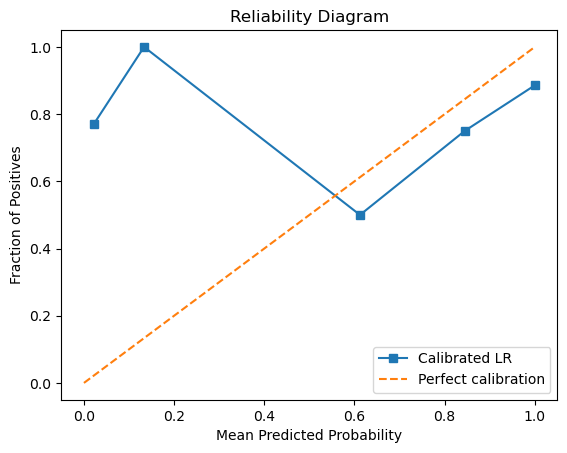

In [43]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted = calibration_curve(y_test, probs, n_bins=10)

plt.plot(mean_predicted, fraction_of_positives, 's-', label='Calibrated LR')
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Reliability Diagram')
plt.show()

In [162]:
print(probs.std())   # probably very low
print(probs.min(), probs.max())

# Check feature importance
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': abs(lr.estimator_.coef_[0])
}).sort_values('coefficient', ascending=False)
print(coef_df.head(10))

0.08922453392621427
0.6 1.0


AttributeError: 'LogisticRegressionCV' object has no attribute 'estimator_'

Baseline Brier: 0.0775

Logistic Regression: Brier=0.0720  Skill=0.0702  Mean prob=0.899
Random Forest: Brier=0.0711  Skill=0.0826  Mean prob=0.906
XGBoost: Brier=0.0716  Skill=0.0753  Mean prob=0.906


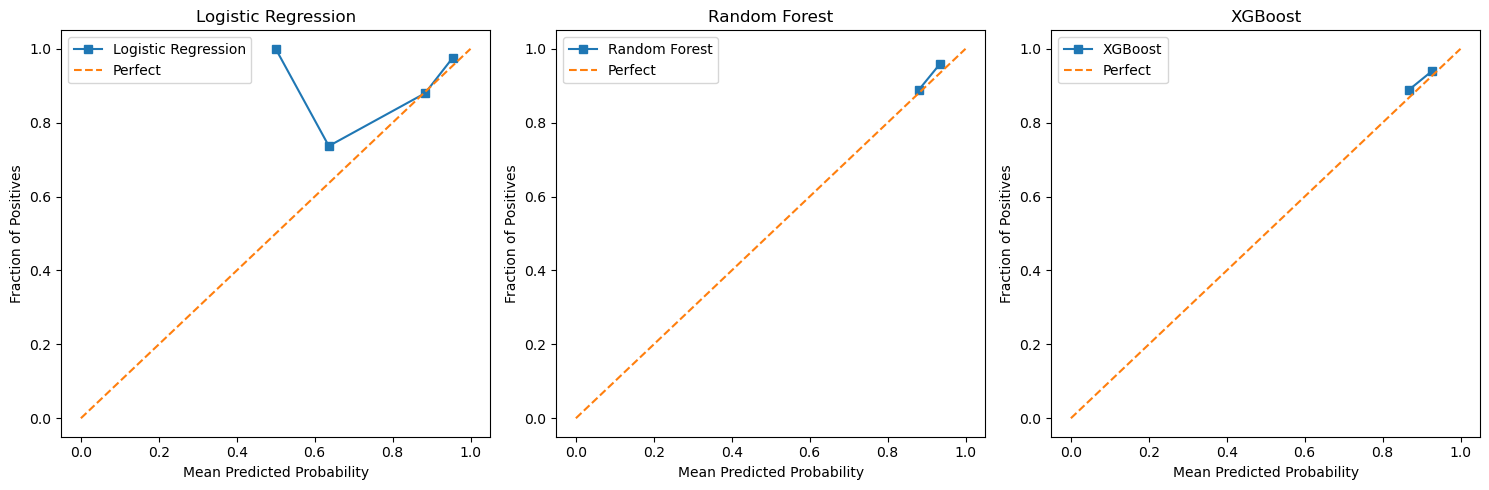

In [40]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Split BEFORE anything
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2)

# Step 1: scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)      # ✅ transform only
X_test_scaled = scaler.transform(X_test)    # ✅ transform only

# ── Base models ──────────────────────────────────────────────
lr = LogisticRegressionCV(class_weight='balanced', cv=5, max_iter=1000)
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), 
                     random_state=42)  # xgboost uses this instead of class_weight

# ── Train on train set ────────────────────────────────────────
lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

# ── Calibrate on validation set ───────────────────────────────
cal_lr  = CalibratedClassifierCV(lr,  method='isotonic', cv='prefit')
cal_rf  = CalibratedClassifierCV(rf,  method='isotonic', cv='prefit')
cal_xgb = CalibratedClassifierCV(xgb, method='isotonic', cv='prefit')

cal_lr.fit(X_val_scaled,  y_val)
cal_rf.fit(X_val_scaled,  y_val)
cal_xgb.fit(X_val_scaled, y_val)

# ── Evaluate on test set ──────────────────────────────────────
models = {
    'Logistic Regression': cal_lr,
    'Random Forest':       cal_rf,
    'XGBoost':             cal_xgb
}

baseline = brier_score_loss(y_test, np.full(len(y_test), y_train.mean()))
print(f"Baseline Brier: {baseline:.4f}\n")

for name, model in models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    brier = brier_score_loss(y_test, probs)
    skill = 1 - (brier / baseline)
    print(f"{name}: Brier={brier:.4f}  Skill={skill:.4f}  Mean prob={probs.mean():.3f}")

# ── Reliability diagrams ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    
    ax.plot(mean_pred, fraction_pos, 's-', label=name)
    ax.plot([0, 1], [0, 1], '--', label='Perfect')
    ax.set_title(name)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend()

plt.tight_layout()
plt.show()

In [27]:
for name, model in models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    brier = brier_score_loss(y_test, probs)
    skill = 1 - (brier / baseline)
    print(f"{name}: Brier={brier:.4f}  Skill={skill:.4f}  Mean={probs.mean():.3f}  Std={probs.std():.3f}")

Logistic Regression: Brier=0.1001  Skill=0.1039  Mean=0.878  Std=0.106
Random Forest: Brier=0.1473  Skill=-0.3187  Mean=0.944  Std=0.189
XGBoost: Brier=0.1482  Skill=-0.3268  Mean=0.944  Std=0.208


In [ ]:
# Turn probabilities into actionable tiers
def risk_tier(prob):
    if prob >= 0.85:
        return 'High Risk - Immediate Review'
    elif prob >= 0.70:
        return 'Medium Risk - Monitor Closely'
    else:
        return 'Low Risk - Routine Monitoring'

results_df = pd.DataFrame({
    'vehicle': X_test.index,
    'recall_probability': lr_proba,
    'risk_tier': [risk_tier(p) for p in lr_proba]
}).sort_values('recall_probability', ascending=False)

print(results_df.head(20))